# Credit Card Fraud Detection — Model Training & Comparison

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## 2. Load Processed Data
Loading the train/test splits (original and SMOTE-balanced) saved from the EDA & Preprocessing notebook.

In [2]:
X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = joblib.load('../data/processed_data.pkl')

print(X_train.shape, X_train_smote.shape)

(227845, 30) (454902, 30)


## 3. Model Training
Training on SMOTE-balanced data, evaluating on the original (untouched) test set.

### 3.1 Logistic Regression (Baseline)

In [3]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

y_pred_log = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698482164390798


### 3.2 Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9688299436966684


### 3.3 XGBoost

In [5]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.86      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.974522814190392


## 4. Model Comparison

### 4.1 Comparison Table

In [6]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [0.06, 0.82, 0.68],
    'Recall': [0.92, 0.82, 0.86],
    'F1-Score': [0.11, 0.82, 0.76],
    'ROC-AUC': [0.9698, 0.9688, 0.9745]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.06,0.92,0.11,0.9698
1,Random Forest,0.82,0.82,0.82,0.9688
2,XGBoost,0.68,0.86,0.76,0.9745


### 4.2 Comparison Plot

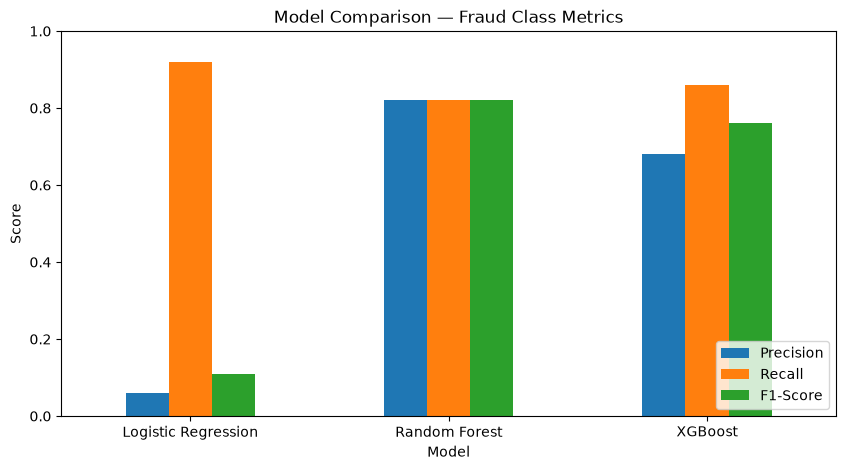

In [7]:
results.set_index('Model')[['Precision','Recall','F1-Score']].plot(kind='bar', figsize=(10,5))
plt.title('Model Comparison — Fraud Class Metrics')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## 5. Save Best Model
Random Forest selected as the final model — best F1-score, most balanced precision/recall for the fraud class.

In [8]:
joblib.dump(rf, '../models/model.pkl')

['../models/model.pkl']